In [3]:
!python3 -m pip install fredapi pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fredapi]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred

fred = Fred (api_key='5b3e75103feed30916d94f08a790f08b')
print('Connected!')

Connected!


In [9]:
!python3 -m pip install certifi
!/Applications/Python\ 3.14/Install\ Certificates.command


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
 -- pip install --upgrade certifi

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
 -- removing any existing file or link
 -- creating symlink to certifi certificate bundle
 -- setting permissions
 -- update complete


In [16]:
import os
print(os.getcwd())

/Users/ShirleyHan


In [17]:
import pandas as pd
import os

print(os.listdir('/Users/Shirleyhan/'))

['Music', '.zprofile.pysave', '.DS_Store', '.CFUserTextEncoding', 'Pictures', '.zprofile', '.zsh_history', '.ipython', 'Desktop', 'Library', '.matplotlib', 'Econ analysis', 'Public', '.idlerc', 'Movies', 'uk_macro_analysis.ipynb', '.Rapp.history', '.Trash', '.ipynb_checkpoints', '.jupyter', '.npm', 'Documents', 'Downloads', '.python_history', '.zsh_sessions']


In [18]:
import pandas as pd
import os

print(os.listdir('/Users/Shirleyhan/'))

['Music', 'CPI.csv', '.zprofile.pysave', '.DS_Store', '.CFUserTextEncoding', 'Pictures', '.zprofile', '.zsh_history', '.ipython', 'Desktop', 'Library', '.matplotlib', 'Econ analysis', 'Public', '.idlerc', 'Movies', 'uk_macro_analysis.ipynb', '.Rapp.history', '.Trash', '.ipynb_checkpoints', '.jupyter', '.npm', 'Documents', 'Unemployment.csv', 'Downloads', '.python_history', 'GDP.csv', '.zsh_sessions']


In [3]:
import pandas as pd
gdp=pd.read_csv('GDP.csv')
print(gdp.head(3))
print(gdp.columns.tolist())

  observation_date  UKNGDP
0       01/01/1955    4666
1       01/04/1955    4688
2       01/07/1955    4862
['observation_date', 'UKNGDP']


In [5]:
gdp = pd.read_csv('GDP.csv', header=0, names=['DATE', 'GDP'])
cpi = pd.read_csv('CPI.csv', header=0, names=['DATE', 'CPI'])
unemployment = pd.read_csv('Unemployment.csv', header=0, names=['DATE', 'Unemployment'])

gdp['DATE'] = pd.to_datetime(gdp['DATE'])
cpi['DATE'] = pd.to_datetime(cpi['DATE'])
unemployment['DATE'] = pd.to_datetime(unemployment['DATE'])

gdp.set_index('DATE', inplace=True)
cpi.set_index('DATE', inplace=True)
unemployment.set_index('DATE', inplace=True)

print(gdp.tail(3))
print(cpi.tail(3))
print(unemployment.tail(3))

               GDP
DATE              
2025-01-04  757927
2025-01-07  764673
2025-01-10  769261
              CPI
DATE             
2025-01-01  135.1
2025-01-02  135.6
2025-01-03  136.1
            Unemployment
DATE                    
2025-01-09           5.1
2025-01-10           5.1
2025-01-11           5.2


In [6]:
gdp=gdp['2000-01-01':]
cpi=cpi['2000-01-01':]
unemployment=unemployment['2000-01-01':]

print(f'GDP:{len(gdp)} data points')
print(f'CPI:{len(cpi)} data points')
print(f'Unemployment:{len(unemployment)} data points')

GDP:104 data points
CPI:303 data points
Unemployment:311 data points


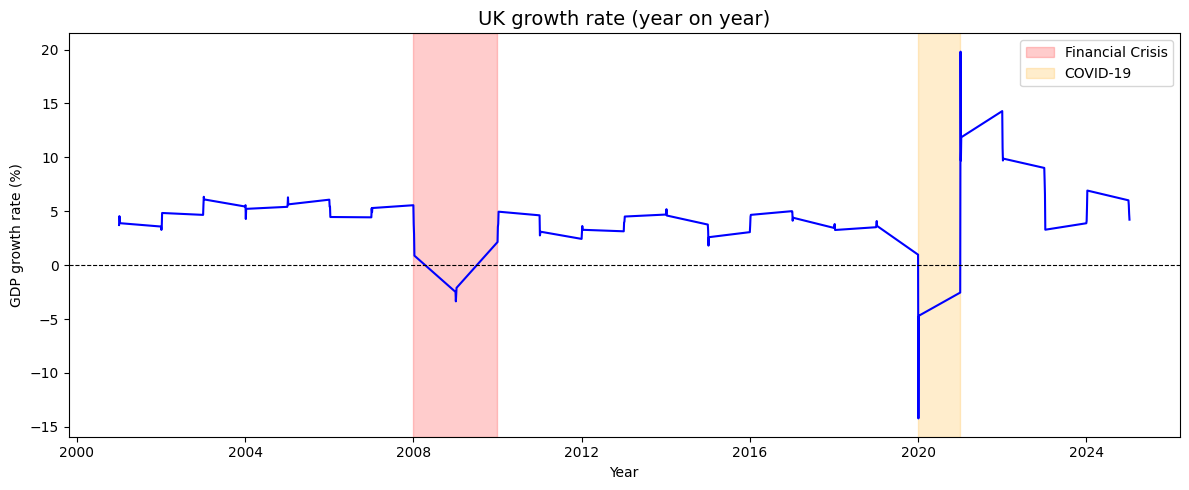

In [10]:
import matplotlib.pyplot as plt

#Calculate year on year GDP growth rate
gdp['GDP_growth']=gdp['GDP'].pct_change(4) * 100

fig, ax=plt.subplots(figsize=(12,5))
ax.plot(gdp.index, gdp['GDP_growth'], color='blue', linewidth=1.5)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)

ax.axvspan('2008-01-01', '2009-12-31', alpha=0.2, color='red', label='Financial Crisis')
ax.axvspan('2020-01-01', '2020-12-31', alpha=0.2, color='orange', label='COVID-19')

ax.set_title('UK growth rate (year on year)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('GDP growth rate (%)')
ax.legend()

plt.tight_layout()
plt.show()

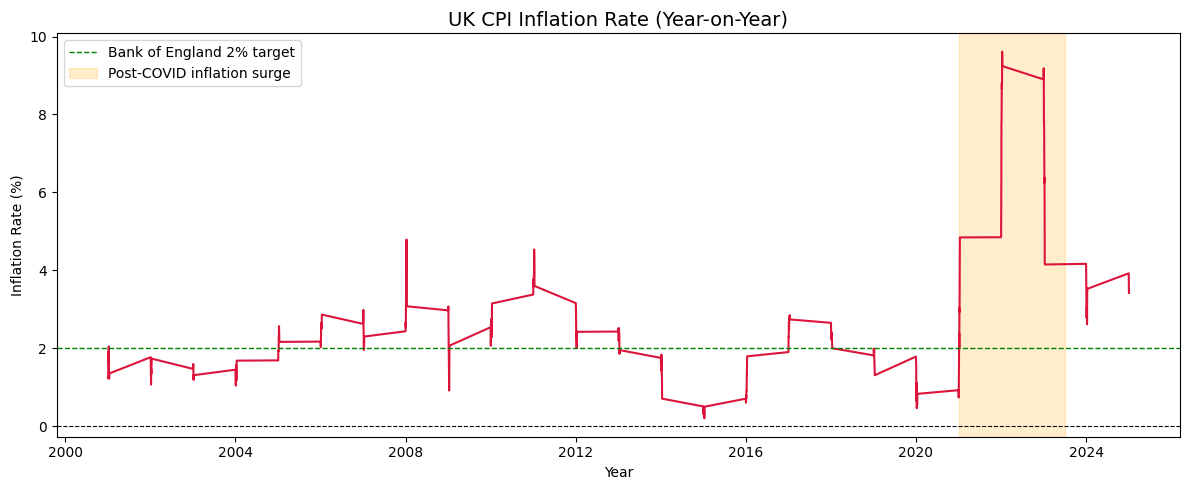

In [11]:
# Calculate year-on-year CPI inflation rate
cpi['CPI_inflation'] = cpi['CPI'].pct_change(12) * 100

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(cpi.index, cpi['CPI_inflation'], color='crimson', linewidth=1.5)
ax.axhline(y=2, color='green', linestyle='--', linewidth=1, label='Bank of England 2% target')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)

ax.axvspan('2021-01-01', '2023-06-30', alpha=0.2, color='orange', label='Post-COVID inflation surge')

ax.set_title('UK CPI Inflation Rate (Year-on-Year)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Inflation Rate (%)')
ax.legend()

plt.tight_layout()
plt.show()

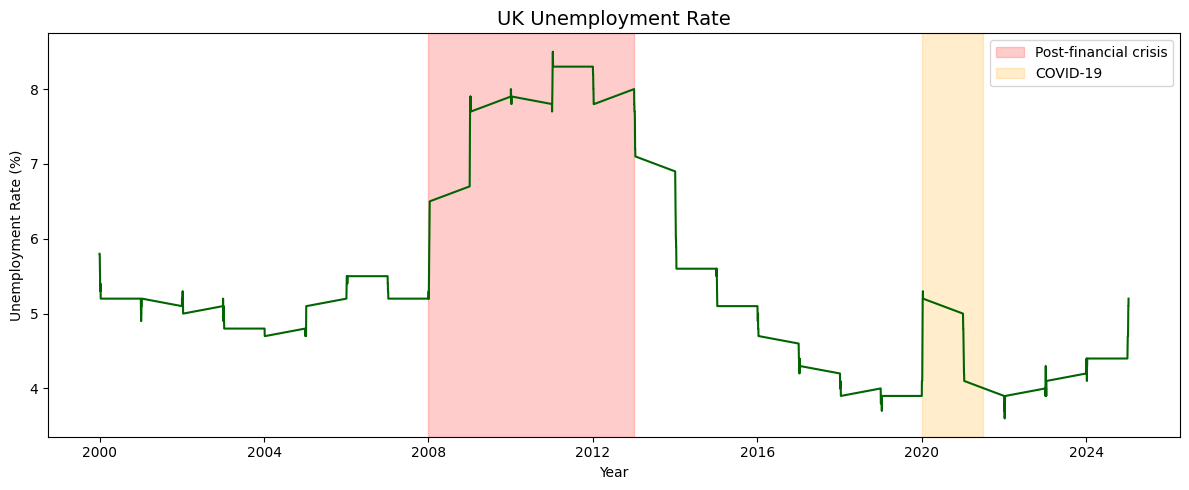

In [12]:
fig,ax = plt.subplots(figsize=(12,5))
ax.plot(unemployment.index, unemployment['Unemployment'], color='darkgreen', linewidth=1.5)
ax.axvspan('2008-01-01', '2013-01-01', alpha=0.2, color='red', label='Post-financial crisis')
ax.axvspan('2020-01-01', '2021-06-30', alpha=0.2, color='orange', label='COVID-19')
ax.set_title('UK Unemployment Rate', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

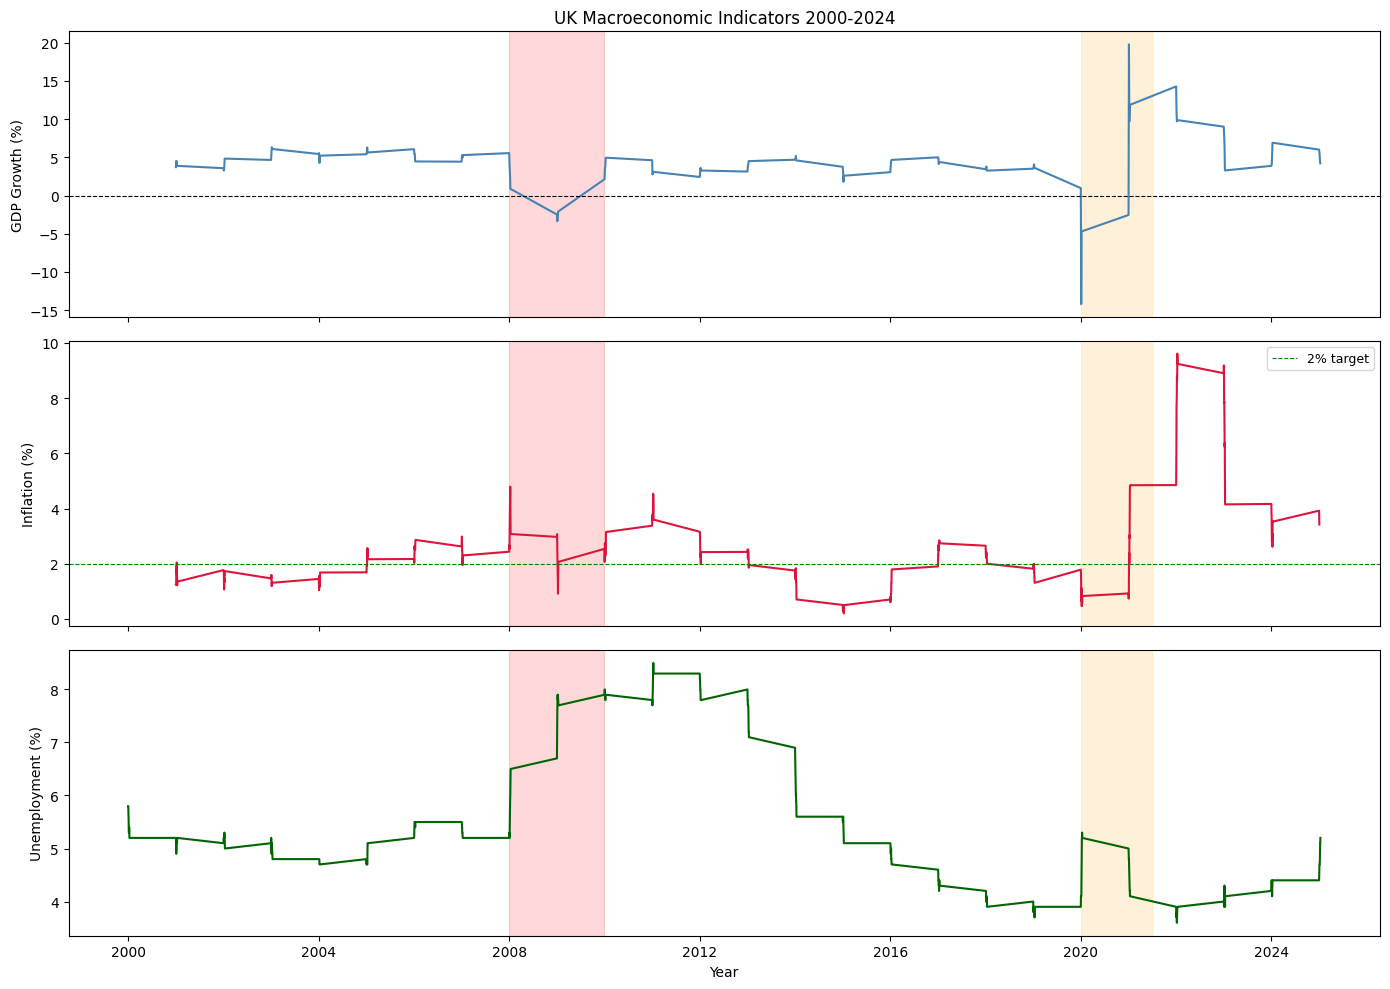

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# GDP growth
ax1.plot(gdp.index, gdp['GDP_growth'], color='steelblue', linewidth=1.5)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax1.set_ylabel('GDP Growth (%)')
ax1.set_title('UK Macroeconomic Indicators 2000-2024')

# CPI inflation
ax2.plot(cpi.index, cpi['CPI_inflation'], color='crimson', linewidth=1.5)
ax2.axhline(y=2, color='green', linestyle='--', linewidth=0.8, label='2% target')
ax2.set_ylabel('Inflation (%)')
ax2.legend(fontsize=9)

# Unemployment
ax3.plot(unemployment.index, unemployment['Unemployment'], color='darkgreen', linewidth=1.5)
ax3.set_ylabel('Unemployment (%)')
ax3.set_xlabel('Year')

# Mark key events on all three
for ax in [ax1, ax2, ax3]:
    ax.axvspan('2008-01-01', '2009-12-31', alpha=0.15, color='red')
    ax.axvspan('2020-01-01', '2021-06-30', alpha=0.15, color='orange')

plt.tight_layout()
plt.show()

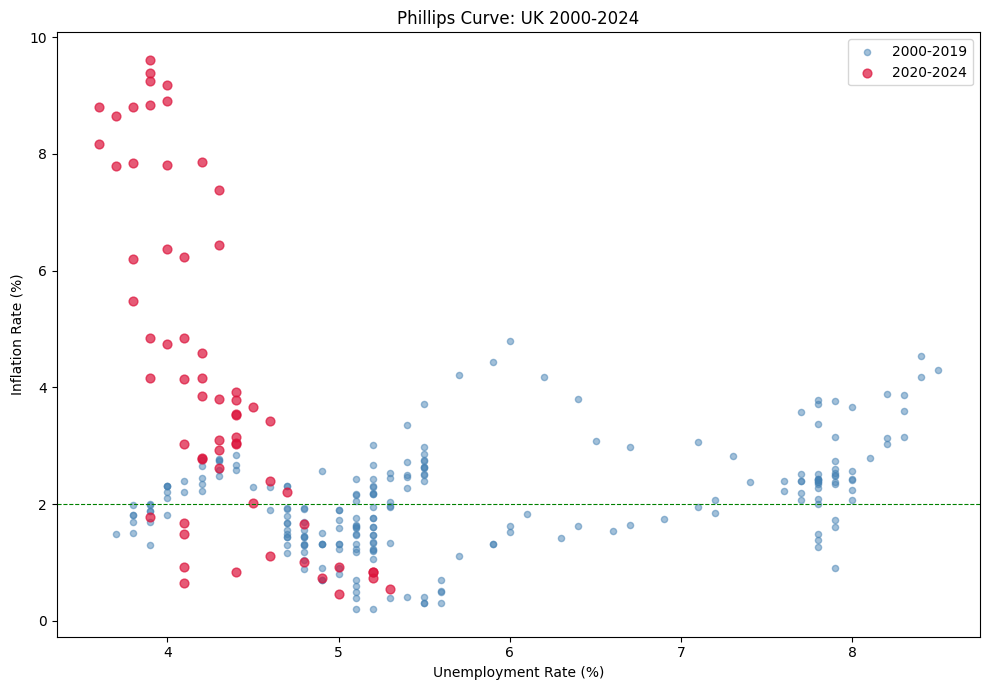

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Align CPI and unemployment to the same dates (monthly)
cpi_monthly = cpi['CPI_inflation'].dropna()
unemp_monthly = unemployment['Unemployment'].dropna()

# Combine into one dataframe
phillips = pd.DataFrame({
    'inflation': cpi_monthly,
    'unemployment': unemp_monthly
}).dropna()

# Split into two periods
pre_covid = phillips['2000-01-01':'2019-12-31']
post_covid = phillips['2020-01-01':]

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(pre_covid['unemployment'], pre_covid['inflation'], 
           color='steelblue', alpha=0.5, label='2000-2019', s=20)
ax.scatter(post_covid['unemployment'], post_covid['inflation'], 
           color='crimson', alpha=0.7, label='2020-2024', s=40)

ax.set_xlabel('Unemployment Rate (%)')
ax.set_ylabel('Inflation Rate (%)')
ax.set_title('Phillips Curve: UK 2000-2024')
ax.legend()
ax.axhline(y=2, color='green', linestyle='--', linewidth=0.8, label='2% target')

plt.tight_layout()
plt.show()

In [ ]:
## Conclusions

### Overview
This analysis examined three key UK macroeconomic indicators — GDP growth, CPI inflation, and unemployment — from 2000 to 2024, 
and the aim of identifying how major economic shocks affected the UK economy and whether traditional textbook economic theroy 
held during these periods.

### Key Findings

1. The 2008 Financial crisis provided a near-textbook validation of Okun's law. As GDP declined by 5%, unemployment rose from
5% to nearly 9% over 3 years -- broadly consistent with the predicted inverse relationship between output and unemployment.
Inflation fell during this period, as weak demand reduced price pressures, which also aligns with traditional macroeconomic
theory. However, the recovery was notably slow -- unemployment did not return to pre-crisis levels until around 2015, a seven-year
recovery, suggesting that while the initial shock followed textbook predictions, the persistence of unemployment points to 
structural factors beyond what Okun's law captures.

2. The scatter plot reveals two distinct regimes. During 2000-2019 (blue), unemployment fluctuated widely between 4-8%, yet
inflation remained near the 2% target -- suggesting the Phillps Curve was effectively flat during this period, likely because
globalisation, improvement in supply chain and well-anchored inflation expectations. During 2020-2024 (red), unemployment remained
low (3.5-5%), but inflation surged to nearly 11% -- not because the labour market tightened further, but because supply-side shocks
(post-COVID disruptions and the 2022 energy price spike) shifted the entire curve upward.

### Policy Implications
The Bank of England raised interest rates from 0.1% to 5.25% between 2021 and 2023 in response to the inflation surge in 2022.
However, using moneytary policy to combat supply-side inflation carries a significant trade-off; it risks suppressing GDP growth
and rising unemployment without directly addressing the underlying supply constraints.

### Limitations
This analysis relies on three indicators and does not account for structural factors such as Brexit, fiscal policy changes,
or global commodity markets, all of which influenced the UK economy during this period.